# 19.4 怎麼確認下一階段真的接著上一階段學？


文字助理接上商品入口時，應該是原來的核心多了一份材料。如果下一站重新建立隨機文字權重，檔名即使也叫 `model.pt`，仍不是接續同一成品。接續訓練因此要保存**檢查點**：除了當時的權重，還可以包含更新器、隨機抽樣與目前步數等狀態。

本章從隨機初始化出發，依下圖走到最終 MoE。每支箭頭載入自己上一段依驗證選出的 `best.pt`；不是另取成熟模型或別條路線的零件。Dense也有自己的完整前段鏈，最終停在weighted joint。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

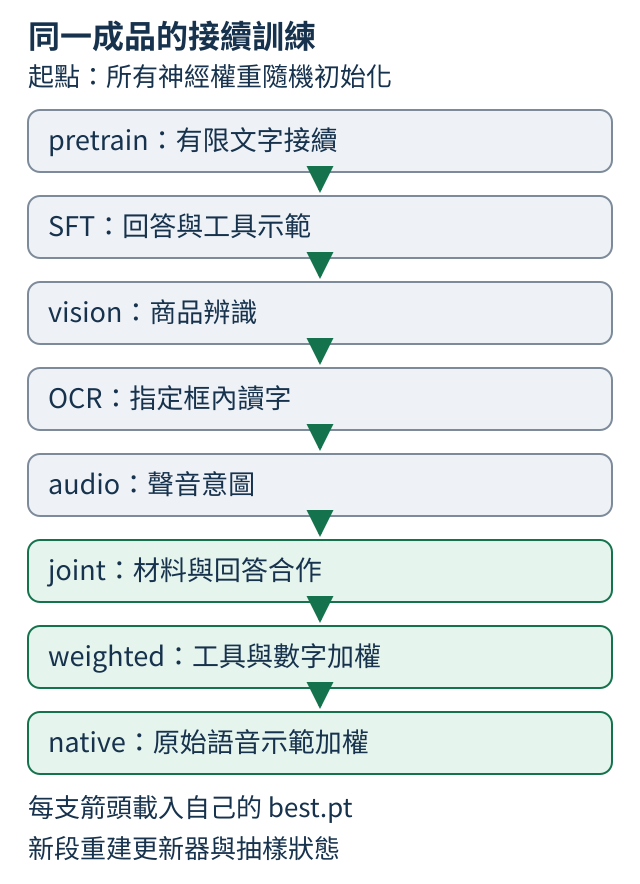

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/p6-19-start-lineage.svg")))

三個感知階段先練入口本身的辨識；到joint才一起練「讀材料後回答」。骨幹是提取特徵的部分，head是給類別或字元打分的部分。joint凍結這些感知零件，也就是保留既有權重、不在這段更新它們；仍允許更新共同文字核心，以及把感知特徵交給核心的接頭。

| 新的一段 | 這段主要學什麼 | 允許更新的模組 |
| --- | --- | --- |
| pretrain | 用有限文字練下一個編號 | 文字核心 |
| SFT | 按示範產生助理回答及工具請求 | 文字核心 |
| vision | 從三類商品像素判斷類別 | 商品入口；文字核心凍結 |
| OCR | 從指定框辨識12字及字序 | 讀字入口；文字核心凍結 |
| audio | 從完整聲學時間序列辨識三種意圖 | 聲音入口；文字核心凍結 |
| joint | 混合文字、商品、讀字、聲音與工具題 | 文字核心與感知接頭；骨幹及辨識head凍結 |
| weighted joint | 加重工具示範和數字位置的訓練誤差 | 同joint；tool權重4、numeric權重4 |
| MoE native joint | 再加重未增強的語音問答與續聊示範 | 同joint；tool權重4、numeric權重1、native voice權重4 |

末兩段仍使用同一模型和資料，只改訓練誤差的比重。驗證維持原本未加這些權重的判準；訓練目標比較重視哪種題，不會直接變成答對證據。聲音head預測的是意圖，沒有把語音轉成逐字稿的ASR。

開始新段與接著中斷點做，是兩個不同動作：

| 要做的事 | 讀入檔案 | 權重以外的狀態 |
| --- | --- | --- |
| `--init-checkpoint`：開始下一段 | 自己前段的驗證選定 `best.pt` | 重建optimizer；依該段seed重新開始抽樣；新段步數、token計數歸零 |
| `--resume`：恢復同一段 | 自己同段的 `latest.pt` | 恢復optimizer、亂數狀態（RNG）、抽題狀態（sampler）和計數；保持原目標與求解設定 |

所以把tool4/numeric4改成tool4/numeric1/native4，要開新的native段；它不能冒充原weighted段的精確續跑。`--steps`在續跑時是那一段的總目標步數，也不是額外再做的步數。

選定檔案也不一定是最後檔案。本章MoE native完成了4,000步，發布的是驗證選中的第1,000步。下面只讀取隨專案保存的紀錄，CPU與Notebook都能離線執行，不需下載權重或重做訓練。


In [3]:
import json
from pathlib import Path

repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "docs/selftrained/v2-manifest.json").is_file())
index = json.loads((repo / "docs/selftrained/v2-training-stage-index.json").read_text())
for row in index["stages"]:
    if row["stage_key"].startswith("moe-"):
        print(row["stage_key"], "完成", row["completed_steps"], "選定", row["selected_step"])
selection = json.loads((repo / "docs/selftrained/results/v2-final-training-source-selection.json").read_text())
native = selection["moe_joint"]
print("moe-native", "完成", native["completed_requested_steps"], "選定", native["selected_step"])

moe-pretrain 完成 1000 選定 250
moe-sft 完成 8000 選定 8000
moe-vision 完成 1200 選定 1200
moe-ocr 完成 3000 選定 3000
moe-audio 完成 1000 選定 200
moe-joint 完成 6000 選定 2000
moe-native 完成 4000 選定 1000


前六行依次列出MoE的pretrain、SFT、vision、OCR、audio與joint；最後一行會印出 `moe-native 完成 4000 選定 1000`。這些欄位說明權重取自哪裡；選得較早或驗證loss較低，都不等於整份生成考卷通過。

<details>
<summary>操作：用本機 wrapper 開始及接續自己的訓練</summary>

這是重做成品的配方，不是本頁短程式的一部分。先依[TRAINING.md](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/selftrained/TRAINING.md)取得並逐檔驗證固定資料，放在 `data/selftrained-v2`；以下從repository根目錄執行。每個輸出目錄必須是新的。第一段從隨機權重開始：

```bash
uv run --frozen --extra cpu --extra selftrained python scripts/selftrained/train_local_stage.py \
  --manifest docs/selftrained/v2-manifest.json \
  --manifest-sha256 3443e3d32ff1e63f8126c2327011be541238765824623af9c8fdcff6b056cb1b \
  --data-root data/selftrained-v2 -- \
  --output-dir checkpoints/selftrained-local/moe-pretrain \
  --stage pretrain --architecture moe --steps 1000 \
  --batch-size 16 --context 512 --seed 20261006 \
  --learning-rate 0.001 --eval-every 250 --save-every 250 --device cpu
```

接著依操作頁的逐段參數，完成自己的SFT、vision、OCR、audio、joint、weighted；每段都用 `--init-checkpoint` 載入自己上一段的 `best.pt`，並沿用同一manifest、batch16、context512和seed。當自己的weighted確實完成後，開新native段的完整命令是：

```bash
uv run --frozen --extra cpu --extra selftrained python scripts/selftrained/train_local_stage.py \
  --manifest docs/selftrained/v2-manifest.json \
  --manifest-sha256 3443e3d32ff1e63f8126c2327011be541238765824623af9c8fdcff6b056cb1b \
  --data-root data/selftrained-v2 -- \
  --output-dir checkpoints/selftrained-local/moe-native \
  --stage joint --architecture moe --steps 4000 \
  --batch-size 16 --context 512 --seed 20261006 \
  --learning-rate 0.0002 --eval-every 1000 --save-every 1000 \
  --freeze-perception-backbones --sampling-mode task-family \
  --tool-loss-weight 4 --numeric-run-loss-weight 1 --native-voice-loss-weight 4 \
  --init-checkpoint checkpoints/selftrained-local/moe-weighted/best.pt --device cpu
```

Native只接受同架構、真正完成的tool4/numeric4 weighted來源及其驗證選定best。Wrapper會核對來源的執行紀錄與指紋，保存本次真實命令、執行結果與checkpoint。未完成的attempt可用自己的 `latest.pt` 恢復同段，不能當作下一段的完成來源；續跑的完整例子見[新stage與exact resume](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/selftrained/TRAINING.md#新-stage-與-exact-resume)。

Dense使用自己的 `dense-*` 目錄與 `--architecture dense`，沿完整前段鏈接自己的來源；本章發布的Dense停在weighted段。公開safe檔供推論，沒有optimizer等續訓狀態；這套訓練從自己產生的完整checkpoint接續。

</details>

核對接續時，要比較真正載入的父檢查點SHA-256與前段選定檔案的完整64字元指紋，再確認執行紀錄確實完成該段；只看相同檔名不夠。這能確認同一條權重鏈，是否維持原本的文字、格式與感知回答，還要回到每段的驗證題。下一節先看SFT要教哪些完整示範。
